In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn

In [ ]:
def create_brownianData(N,sigma,T,plot=True):
    delta_t = T/N
    W = np.zeros(N)
    t_grid = [i*delta_t for i in range(N)]
    for t in range(1,N): 
        W[t] = W[t-1]+np.sqrt(delta_t)*np.random.normal(loc=0,scale=delta_t)

    X = sigma*W
    delta_X = X[1:]-X[:-1]
    

    delta_X_tens = torch.tensor(delta_X,dtype=torch.double)
    delta_X_tens = delta_X_tens.unsqueeze(1)
    # print(delta_X_tens.shape)
    sigma_tens = torch.tensor([sigma]*(N-1),dtype=torch.double).unsqueeze(1)
    # print(sigma_tens.shape)

    if plot:
        plt.plot(t_grid,W)
        plt.show()
        plt.plot(t_grid[:-1],delta_X)
        plt.show()

    return delta_X_tens,sigma_tens

def train_simplNet(net,delta_X_tens,sigma_tens,N1=32,epochs=10):
    print(f"sigma = {sigma_tens[0]}")
    d=1
    k=1
    N_ = len(delta_X_tens)
    net = (nn.Sequential(nn.Linear(d,N1),nn.ReLU(),nn.Linear(N1,k))).to(dtype=torch.double)
    l = []
    opt = torch.optim.SGD(net.parameters(),lr=1e-3)
    loss_func = torch.nn.MSELoss()
    for epoch in range(epochs):
        opt.zero_grad()
        for i in range(round(N_/10)):
            j = np.random.randint(0,N_)
            loss = loss_func(net(delta_X_tens[j]),sigma_tens[j])
            loss.backward()
            opt.step()

        l.append(loss.detach().numpy())
        if epoch%5 == 0:
            print(f"Progress: {epoch/epochs}, Loss: {loss.detach():3e} \n")

    return net,l



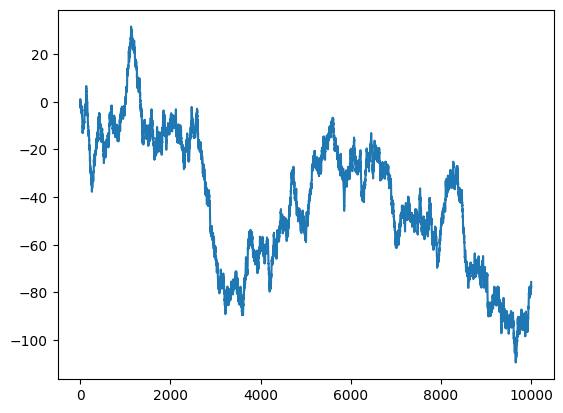

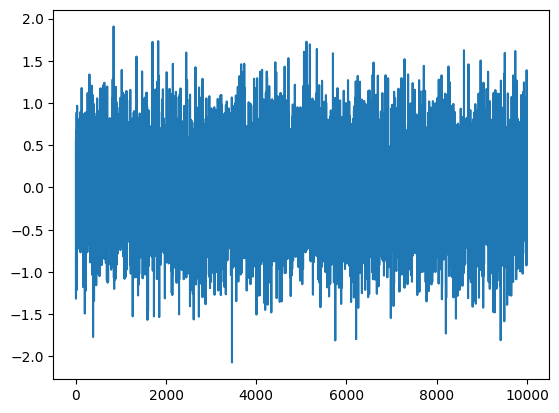

sigma = tensor([0.5000], dtype=torch.float64)
Progress: 0.0, Loss: 8.227912e-02 

Progress: 0.5, Loss: 2.977756e-03 



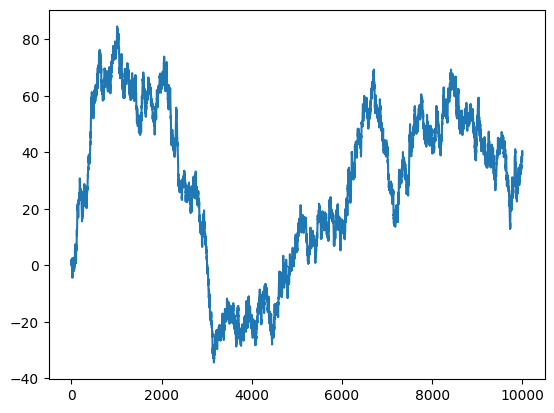

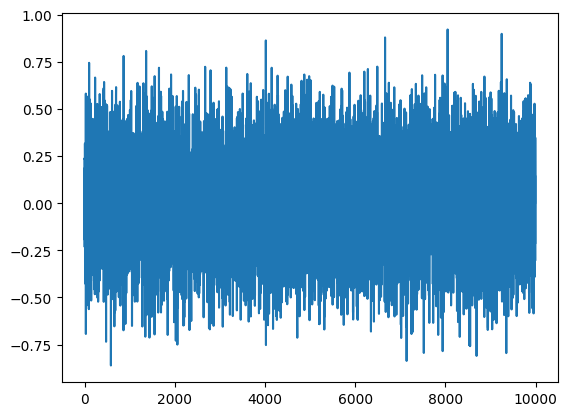

sigma = tensor([0.2500], dtype=torch.float64)
Progress: 0.0, Loss: 4.736211e-02 

Progress: 0.5, Loss: 2.253321e-03 



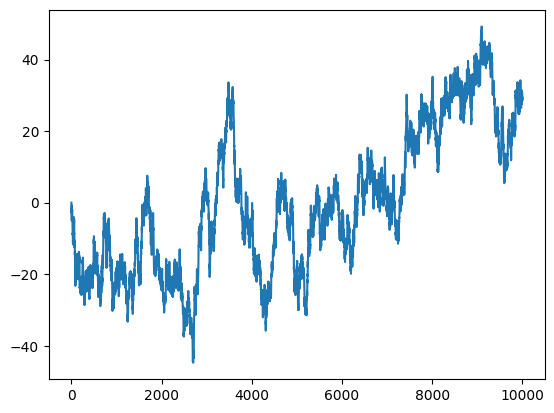

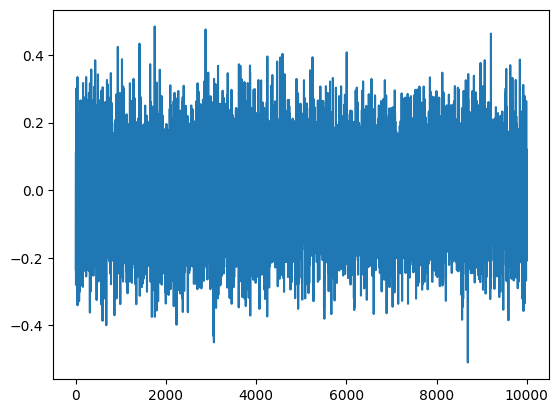

sigma = tensor([0.1250], dtype=torch.float64)
Progress: 0.0, Loss: 4.077013e-02 

Progress: 0.5, Loss: 1.804670e-03 



In [270]:
N = 10_000; T = 10_000
len_ = 3
sigmas = [2**(-i) for i in range(1,len_+1)]

y_preds = []
y_ = []
x_ = []
l_ = []
nets = []

for sigma in sigmas:

    delta_X_tens,sigma_tens = create_brownianData(N,sigma,T,plot=True)
    net,l = train_simplNet(delta_X_tens,sigma_tens)

    y_hat = []
    for i in range(N-1):
        y_hat.append(net(delta_X_tens[i]).detach())
    
    y_preds.append(y_hat)
    l_.append(l)
    y_.append(sigma_tens.detach())
    x_.append(delta_X_tens)
    nets.append(net)



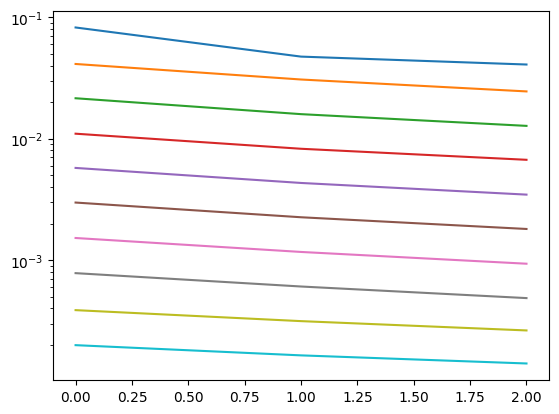

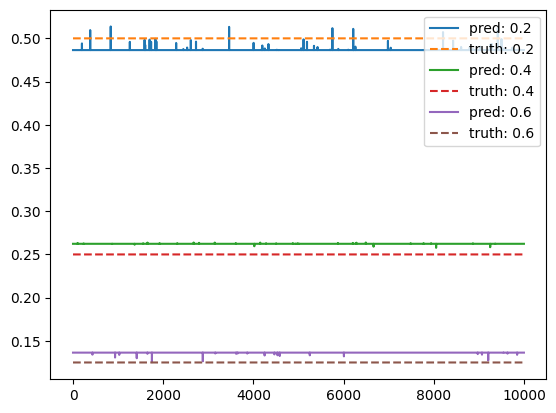

In [281]:
plt.plot(l_)
# plt.plot(y_hat)
plt.yscale("log")
plt.show()

for i in range(len_):
    plt.plot(y_preds[i],label=f"pred: {0.2*(i+1):.2}")
    plt.plot(y_[i],'--',label=f"truth: {0.2*(i+1):.2}")
plt.legend()
plt.show()


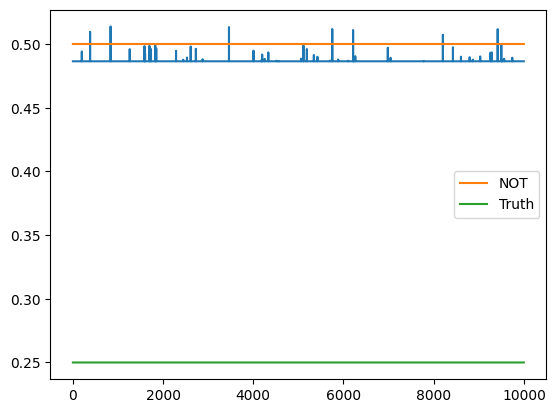

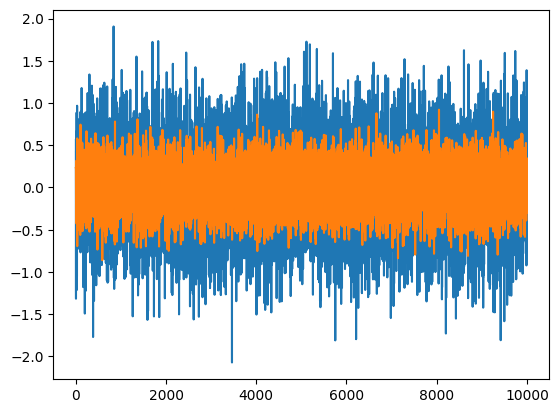

In [278]:
plt.plot(nets[0](x_[0]).detach())
plt.plot(y_[0],label="NOT")
plt.plot(y_[1],label="Truth")
plt.legend()
plt.show()

plt.plot(x_[0])
plt.plot(x_[1])
plt.show()


In [ ]:
print(torch.var(x_[0])

tensor(0.2501, dtype=torch.float64)
